# Lab: Improving CIFAR-10 Classification with Rich Preprocessing and Mini-AlexNet

## Course Context

In previous labs, you worked with CIFAR-10 using `fetch_openml` from scikit-learn. In this lab, you will continue using the same dataset-loading style so that the data preparation step remains familiar.

The difference is that this time you will move from a simpler classification pipeline to a deeper image classification pipeline based on PyTorch.

You will build the following complete computer vision pipeline:

```
OpenML CIFAR-10 data
 |
 v
reshape flattened vectors into images
 |
 v
image preprocessing and data augmentation
 |
 v
PyTorch DataLoader
 |
 v
Mini-AlexNet CNN
 |
 v
classification and evaluation
```

The main goal is to understand that image classification accuracy depends on the **full pipeline**, not only on the neural network architecture.

You will work with three connected ideas:
1. Image preprocessing.
2. Data augmentation.
3. CNN architecture design.

The CNN architecture in this lab is a **Mini-AlexNet**-style network adapted to CIFAR-10 images. CIFAR-10 images are very small (32×32 pixels, 3 color channels). The original AlexNet was designed for much larger images, so you will use its general idea with smaller kernels and less aggressive downsampling.

## Main Idea of the Lab

The central question:

> **Can you improve CIFAR-10 classification accuracy by improving the image preprocessing pipeline, adding data augmentation, and using a stronger CNN architecture?**

You will compare three image pipelines:

| Pipeline | Description |
|---|---|
| Basic preprocessing | Convert image to tensor and normalize it |
| Augmented preprocessing | Add random crop and horizontal flip |
| Rich preprocessing | Add OpenCV contrast enhancement and mild sharpening, then apply augmentation |

All three pipelines will use the same CNN architecture: **Mini-AlexNet**.

---
# Task 1: Prepare CIFAR-10 from OpenML and Build the Data Pipeline

## 1.1 Install Required Libraries

If you are using Google Colab or a fresh Python environment, run the following cell.
If your environment already has these packages installed, you can skip this cell.

In [ ]:
# If needed, uncomment and run this cell.
# !pip install torch torchvision matplotlib scikit-learn opencv-python pillow

## 1.2 Import the Required Libraries

| Library | Purpose |
|---|---|
| scikit-learn | Load CIFAR-10 from OpenML, split data, evaluation metrics |
| PyTorch | CNN model, tensors, training, optimization |
| torchvision | Image transformations |
| OpenCV | Extra image preprocessing |
| NumPy | Array operations |
| matplotlib | Visualization |
| PIL | Image conversion between formats |

In [ ]:
import os
import random
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

## 1.3 Configure the Experiment

In deep learning experiments, it is useful to define the most important configuration values in one place.

The code below controls:
1. Random seed.
2. Device selection.
3. Batch size.
4. Number of training epochs.
5. Learning rate.
6. Weight decay.

> **Tip:** If training is too slow on your machine, reduce `EPOCHS` from 5 to 2.

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_WORKERS = 0
EPOCHS = 5
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

print("Using device:", DEVICE)

Using device: cuda


## 1.4 Define the CIFAR-10 Class Names

CIFAR-10 contains 10 object classes. The class labels in OpenML are usually stored as numeric values from 0 to 9.

In [ ]:
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

NUM_CLASSES = len(CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
for idx, name in enumerate(CLASS_NAMES):
    print(idx, "->", name)

Number of classes: 10
0 -> airplane
1 -> automobile
2 -> bird
3 -> cat
4 -> deer
5 -> dog
6 -> frog
7 -> horse
8 -> ship
9 -> truck


## 1.5 Load CIFAR-10 Using fetch_openml

OpenML provides CIFAR-10 in a **flattened format**. This means each image is stored as one long vector instead of a 32×32×3 image.

For CIFAR-10: `32 × 32 × 3 = 3072 values per image`

The version commonly used in introductory labs is `CIFAR_10_small`.

In [ ]:
openml_dataset = fetch_openml(
    name="CIFAR_10_small",
    version=1,
    as_frame=False
)

X_flat = openml_dataset.data
y_raw = openml_dataset.target

print("Data shape:", X_flat.shape)
print("Target shape:", y_raw.shape)
print("Data type:", X_flat.dtype)
print("Target examples:", y_raw[:10])

Data shape: (20000, 3072)
Target shape: (20000,)
Data type: int64
Target examples: ['6' '9' '9' '4' '1' '1' '2' '7' '8' '3']


## 1.6 Convert Labels to Integers

OpenML targets are sometimes loaded as strings. For PyTorch training, labels should be integer class indices.

In [ ]:
y = y_raw.astype(np.int64)
print("Unique labels:", np.unique(y))
print("Number of labels:", len(np.unique(y)))

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of labels: 10


## 1.7 Convert Flattened Vectors into RGB Images

CIFAR-10 stores the channel values in the following order:

> **1024 red values, followed by 1024 green values, followed by 1024 blue values**

Therefore, you will first reshape each image to `3 × 32 × 32`, then transpose it to the more common image format `32 × 32 × 3`.

In [ ]:
if X_flat.shape[1] != 3072:
    raise ValueError("Expected each CIFAR-10 image to have 3072 features.")

X_images = X_flat.reshape(-1, 3, 32, 32)
X_images = X_images.transpose(0, 2, 3, 1)
X_images = np.clip(X_images, 0, 255).astype(np.uint8)

print("Image array shape:", X_images.shape)
print("Image data type:", X_images.dtype)
print("Minimum pixel value:", X_images.min())
print("Maximum pixel value:", X_images.max())

Image array shape: (20000, 32, 32, 3)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


## 1.8 Visualize Raw Images

Before building the CNN, you should always inspect some images. This helps you check that the reshaping step was correct.

> **NOTE:** If you see some images from the same class, note how much is the visual difference between the images — this is what makes recognition not an easy task.

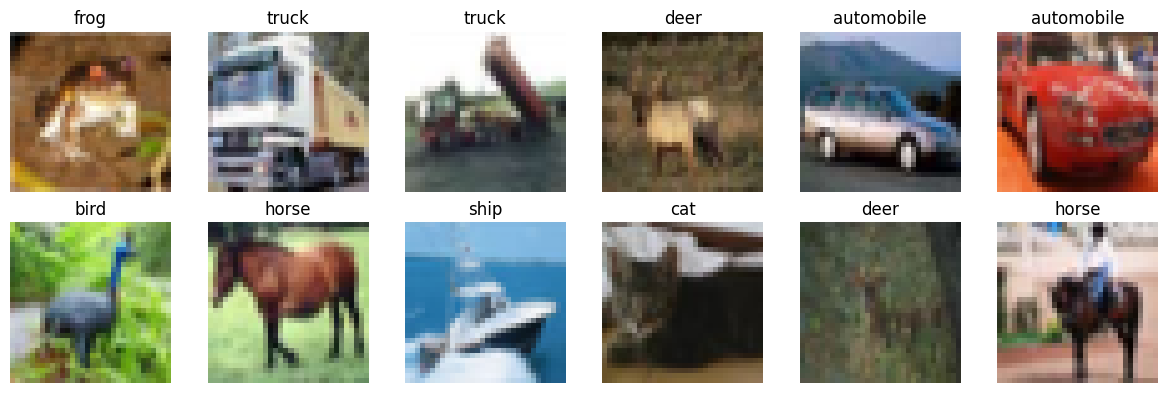

In [ ]:
def show_raw_examples(images, labels, class_names, num_images=12):
    plt.figure(figsize=(12, 4))
    for i in range(num_images):
        image = images[i]
        label = labels[i]
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_raw_examples(X_images, y, CLASS_NAMES, num_images=12)

## 1.9 Create Training, Validation, and Test Splits

Unlike `torchvision.datasets.CIFAR10`, the OpenML version does not directly give you the original train/test split. You will create your own **stratified split**:

- **70%** training
- **15%** validation
- **15%** testing

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_images,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Test images:", X_test.shape)
print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training images: (14000, 32, 32, 3)
Validation images: (3000, 32, 32, 3)
Test images: (3000, 32, 32, 3)
Training labels: (14000,)
Validation labels: (3000,)
Test labels: (3000,)


## 1.10 Check Class Balance

In [ ]:
def print_class_distribution(labels, class_names, title):
    counts = np.bincount(labels, minlength=len(class_names))
    print(title)
    print("-" * len(title))
    for idx, count in enumerate(counts):
        print(f"{idx:2d} {class_names[idx]:12s}: {count}")
    print()

print_class_distribution(y_train, CLASS_NAMES, "Training set distribution")
print_class_distribution(y_val, CLASS_NAMES, "Validation set distribution")
print_class_distribution(y_test, CLASS_NAMES, "Test set distribution")

Training set distribution
-------------------------
 0 airplane    : 1404
 1 automobile  : 1382
 2 bird        : 1422
 3 cat         : 1411
 4 deer        : 1399
 5 dog         : 1356
 6 frog        : 1421
 7 horse       : 1401
 8 ship        : 1417
 9 truck       : 1387

Validation set distribution
---------------------------
 0 airplane    : 300
 1 automobile  : 296
 2 bird        : 305
 3 cat         : 303
 4 deer        : 300
 5 dog         : 290
 6 frog        : 305
 7 horse       : 300
 8 ship        : 304
 9 truck       : 297

Test set distribution
---------------------
 0 airplane    : 301
 1 automobile  : 296
 2 bird        : 305
 3 cat         : 302
 4 deer        : 300
 5 dog         : 291
 6 frog        : 304
 7 horse       : 300
 8 ship        : 304
 9 truck       : 297



## 1.11 Compute Normalization Values from the Training Set

> **Important rule:** Compute normalization statistics using **only the training set**. You should not compute them using the validation or test set, because validation and test data should simulate unseen data.

In [ ]:
def compute_channel_mean_std(images):
    images_float = images.astype(np.float32) / 255.0
    mean = images_float.mean(axis=(0, 1, 2))
    std = images_float.std(axis=(0, 1, 2))
    return mean, std

CIFAR10_MEAN, CIFAR10_STD = compute_channel_mean_std(X_train)
CIFAR10_MEAN = tuple(CIFAR10_MEAN.tolist())
CIFAR10_STD = tuple(CIFAR10_STD.tolist())

print("Training set mean:", CIFAR10_MEAN)
print("Training set std:", CIFAR10_STD)

Training set mean: (0.4938886761665344, 0.48401275277137756, 0.44863152503967285)
Training set std: (0.2474883496761322, 0.24400481581687927, 0.2622087597846985)


## 1.12 Create a PyTorch Dataset Wrapper for OpenML CIFAR-10

This class will:
1. Store the images and labels.
2. Convert each NumPy image into a PIL image.
3. Apply the selected transform.
4. Return the transformed image and its label.

In [ ]:
class OpenMLCIFAR10Dataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]
        image = Image.fromarray(image, mode="RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label

---
# Task 2: Build Rich Preprocessing and Augmentation

You will define three preprocessing pipelines:

| Pipeline | Description |
|---|---|
| Basic | Convert image to tensor and normalize it |
| Augmented | Add random crop and horizontal flip |
| Rich | Add OpenCV preprocessing before augmentation |

## 2.1 Basic Preprocessing

The basic pipeline performs two operations:
1. Convert the PIL image to a PyTorch tensor.
2. Normalize the tensor using the training-set mean and standard deviation.

In [ ]:
basic_train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

basic_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

## 2.2 Augmented Preprocessing

Data augmentation creates random variations of the training images. This pipeline uses:
1. `RandomCrop(32, padding=4)` — teaches the network to be less sensitive to small translations.
2. `RandomHorizontalFlip(p=0.5)` — teaches the network that many objects can appear mirrored.

In [ ]:
augmented_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

augmented_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

## 2.3 Why Not Augment Validation and Test Images?

> **Rule:** Use random augmentation **during training only**. Do **not** use random augmentation during validation or testing.

If you apply random augmentation during validation or testing, the measured accuracy can change every time you run the evaluation — making comparisons unfair.

## 2.4 OpenCV Preprocessing Transform

This transform applies:
1. Conversion from RGB to LAB color space.
2. **CLAHE** (Contrast Limited Adaptive Histogram Equalization) on the L channel.
3. Conversion back to RGB.
4. Mild sharpening.

> Note: CIFAR-10 images are only 32×32, so strong preprocessing can damage useful information. The sharpening is intentionally mild.

In [ ]:
class OpenCVPreprocess:
    def __init__(self, use_clahe=True, use_sharpen=True):
        self.use_clahe = use_clahe
        self.use_sharpen = use_sharpen

    def __call__(self, image):
        """
        Input:  PIL image in RGB format
        Output: PIL image in RGB format after OpenCV preprocessing
        """
        img = np.array(image)

        if self.use_clahe:
            lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            l_channel, a_channel, b_channel = cv2.split(lab)
            clahe = cv2.createCLAHE(
                clipLimit=2.0,
                tileGridSize=(4, 4)
            )
            l_channel = clahe.apply(l_channel)
            lab = cv2.merge((l_channel, a_channel, b_channel))
            img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

        if self.use_sharpen:
            blurred = cv2.GaussianBlur(img, (3, 3), 0)
            img = cv2.addWeighted(img, 1.2, blurred, -0.2, 0)

        img = np.clip(img, 0, 255).astype(np.uint8)
        return Image.fromarray(img, mode="RGB")

## 2.5 Rich Preprocessing and Augmentation Pipeline

The rich pipeline applies OpenCV preprocessing first, then random augmentation, then converts and normalizes.

In [ ]:
rich_train_transform = transforms.Compose([
    OpenCVPreprocess(use_clahe=True, use_sharpen=True),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

rich_eval_transform = transforms.Compose([
    OpenCVPreprocess(use_clahe=True, use_sharpen=True),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

## 2.6 Helper Function to Undo Normalization

To visualize transformed images, you need to undo normalization. The model needs normalized tensors, but matplotlib expects image values in the range 0...1 or 0...255.

In [ ]:
def denormalize_tensor(image_tensor, mean=CIFAR10_MEAN, std=CIFAR10_STD):
    mean = torch.tensor(mean, dtype=image_tensor.dtype).view(3, 1, 1)
    std = torch.tensor(std, dtype=image_tensor.dtype).view(3, 1, 1)
    image = image_tensor.cpu() * std + mean
    image = torch.clamp(image, 0, 1)
    return image

## 2.7 Visualize the Effect of Different Transforms

You should look at what preprocessing actually does to the image before training the model.

> **Tip:** Run the cell several times. The raw image and basic transform should stay the same. The augmented and rich versions may change because random crop and random horizontal flip are used.

/tmp/ipykernel_2038/229852957.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  raw_image = Image.fromarray(raw_image_array, mode="RGB")
/tmp/ipykernel_2038/2755696386.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, mode="RGB")


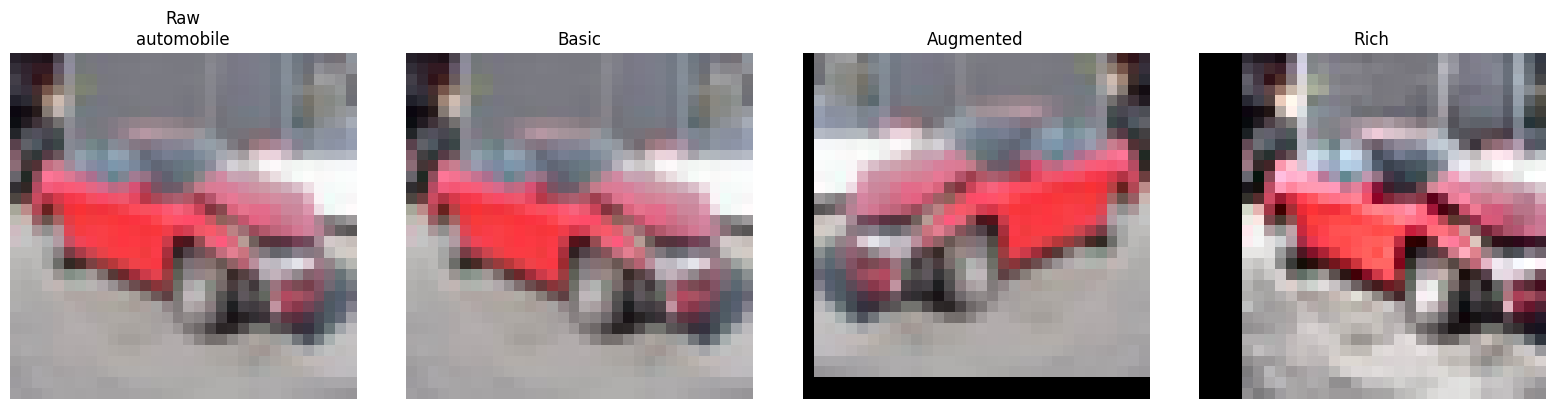

In [ ]:
def show_transform_comparison(images, labels, index, transform_dict, class_names):
    raw_image_array = images[index]
    label = labels[index]
    raw_image = Image.fromarray(raw_image_array, mode="RGB")

    num_versions = 1 + len(transform_dict)
    plt.figure(figsize=(4 * num_versions, 4))

    plt.subplot(1, num_versions, 1)
    plt.imshow(raw_image_array)
    plt.title("Raw\n" + class_names[label])
    plt.axis("off")

    for i, (name, transform) in enumerate(transform_dict.items(), start=2):
        transformed = transform(raw_image)
        if isinstance(transformed, torch.Tensor):
            transformed = denormalize_tensor(transformed)
            transformed = transformed.permute(1, 2, 0).numpy()
        plt.subplot(1, num_versions, i)
        plt.imshow(transformed)
        plt.title(name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


transform_dict = {
    "Basic": basic_train_transform,
    "Augmented": augmented_train_transform,
    "Rich": rich_train_transform
}

show_transform_comparison(
    images=X_train,
    labels=y_train,
    index=10,
    transform_dict=transform_dict,
    class_names=CLASS_NAMES
)

## 2.8 Create DataLoaders

The function below creates PyTorch DataLoader objects for a selected preprocessing pipeline. The same split is used for all experiments — only the transform changes.

In [ ]:
def create_dataloaders(train_transform, eval_transform):
    train_dataset = OpenMLCIFAR10Dataset(
        images=X_train,
        labels=y_train,
        transform=train_transform
    )
    val_dataset = OpenMLCIFAR10Dataset(
        images=X_val,
        labels=y_val,
        transform=eval_transform
    )
    test_dataset = OpenMLCIFAR10Dataset(
        images=X_test,
        labels=y_test,
        transform=eval_transform
    )

    pin_memory = True if DEVICE.type == "cuda" else False

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    return train_loader, val_loader, test_loader

## 2.9 Test One DataLoader

Before training the model, check that the DataLoader returns batches with the correct shape.

The expected image batch shape is: `batch_size × 3 × 32 × 32`

In [ ]:
train_loader, val_loader, test_loader = create_dataloaders(
    train_transform=basic_train_transform,
    eval_transform=basic_eval_transform
)

images_batch, labels_batch = next(iter(train_loader))
print("Image batch shape:", images_batch.shape)
print("Label batch shape:", labels_batch.shape)
print("Image batch dtype:", images_batch.dtype)
print("Label batch dtype:", labels_batch.dtype)

/tmp/ipykernel_2038/66673513.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image batch dtype: torch.float32
Label batch dtype: torch.int64


---
# Task 3: Implement Mini-AlexNet for CIFAR-10

Original AlexNet was designed for large ImageNet images (~224×224). CIFAR-10 images are much smaller (32×32), so you will implement a smaller AlexNet-inspired CNN.

## 3.1 Architecture Overview

Mini-AlexNet has two main parts:
1. **Feature extractor** — convolution, batch normalization, ReLU, and max pooling layers.
2. **Classifier** — fully connected layers and dropout.

Expected feature map sizes:

```
Input image:    3 x 32 x 32
After block 1: 64 x 16 x 16
After block 2: 128 x  8 x  8
After block 3: 256 x  8 x  8
After block 4: 256 x  4 x  4
Flattened:     256 * 4 * 4 = 4096
Output:        10 class scores
```

## 3.2 Define the Mini-AlexNet Model

In [ ]:
class MiniAlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super(MiniAlexNet, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # Block 4
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 3.3 Inspect the Model

In [ ]:
model = MiniAlexNet(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

MiniAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxP

## 3.4 Test the Model with a Dummy Input

The output shape should be `4 × 10` — 4 images in the batch, 10 class scores per image.

In [ ]:
dummy_input = torch.randn(4, 3, 32, 32).to(DEVICE)
with torch.no_grad():
    dummy_output = model(dummy_input)

print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)

Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])


## 3.5 Count Trainable Parameters

> **Answer briefly in your notebook:** Why does the final layer have 10 output values?

In [ ]:
def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

num_parameters = count_trainable_parameters(model)
print("Trainable parameters:", num_parameters)

Trainable parameters: 3065098


**Your answer:**

The final layer has 10 output values because the CIFAR-10 dataset contains 10 distinct classes (e.g., airplane, automobile, cat, etc.). The last layer acts as a classifier, so it must produce one score (logit) for each class, representing the model's confidence that the image belongs to that specific category.

---
# Task 4: Train, Evaluate, and Compare Results

You will compare:

| Experiment | Training Transform | Evaluation Transform |
|---|---|---|
| Basic | Basic preprocessing | Basic preprocessing |
| Augmented | Random crop + flip | Basic preprocessing |
| Rich | OpenCV preprocessing + augmentation | OpenCV preprocessing |

## 4.1 Define the Training Function for One Epoch

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs, dim=1)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (predicted == labels).sum().item()
        running_total += batch_size

    epoch_loss = running_loss / running_total
    epoch_accuracy = running_correct / running_total
    return epoch_loss, epoch_accuracy

## 4.2 Define the Evaluation Function

During evaluation:
- Model parameters are **not** updated.
- Gradients are **not** computed.
- Dropout behaves differently (evaluation mode).
- Batch normalization uses learned running statistics.

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (predicted == labels).sum().item()
            running_total += batch_size
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    epoch_loss = running_loss / running_total
    epoch_accuracy = running_correct / running_total
    return epoch_loss, epoch_accuracy, np.array(all_labels), np.array(all_predictions)

## 4.3 Define a Complete Training Function

This function trains the model and keeps the **best model version** according to validation accuracy.

In [ ]:
def train_model(train_loader, val_loader, experiment_name, epochs=EPOCHS):
    model = MiniAlexNet(num_classes=NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    best_val_accuracy = 0.0
    best_model_state = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    print()
    print("Starting experiment:", experiment_name)
    print("-" * 70)

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_accuracy = train_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE
        )

        val_loss, val_accuracy, _, _ = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=DEVICE
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start_time
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Train Acc: {train_accuracy:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_accuracy:.4f} "
            f"Time: {elapsed:.1f}s"
        )

    model.load_state_dict(best_model_state)
    print("-" * 70)
    print(f"Best validation accuracy for {experiment_name}: {best_val_accuracy:.4f}")
    return model, history, best_val_accuracy

## 4.4 Plot Training Curves

Look for:
1. Training loss decreasing.
2. Validation loss decreasing or stabilizing.
3. Training accuracy increasing.
4. Validation accuracy increasing.
5. Large gaps between training and validation accuracy (may indicate overfitting).

In [ ]:
def plot_history(history, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Training Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_accuracy"], label="Training Accuracy")
    plt.plot(epochs_range, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

## 4.5 Define the Experiments

In [ ]:
EXPERIMENTS = {
    "basic": {
        "train_transform": basic_train_transform,
        "eval_transform": basic_eval_transform,
        "description": "Basic tensor conversion and normalization"
    },
    "augmented": {
        "train_transform": augmented_train_transform,
        "eval_transform": augmented_eval_transform,
        "description": "Random crop and horizontal flip during training"
    },
    "rich": {
        "train_transform": rich_train_transform,
        "eval_transform": rich_eval_transform,
        "description": "OpenCV preprocessing plus training augmentation"
    }
}

print("Available experiments:")
for name, config in EXPERIMENTS.items():
    print(f"{name:10s}: {config['description']}")

Available experiments:
basic     : Basic tensor conversion and normalization
augmented : Random crop and horizontal flip during training
rich      : OpenCV preprocessing plus training augmentation


## 4.6 Choose Which Experiments to Run

- If you have a **GPU**: run all three experiments.
- If you are using **CPU only** and training is slow: run only one experiment first.

In [ ]:
# For a full comparison:
experiments_to_run = ["basic", "augmented", "rich"]

# For a faster CPU run, you may use this instead:
# experiments_to_run = ["rich"]

## 4.7 Train and Evaluate the Experiments


Starting experiment: basic
----------------------------------------------------------------------


/tmp/ipykernel_2038/66673513.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


Epoch [1/5] Train Loss: 1.8918 Train Acc: 0.3245 Val Loss: 1.7398 Val Acc: 0.3727 Time: 7.5s
Epoch [2/5] Train Loss: 1.4625 Train Acc: 0.4576 Val Loss: 1.3000 Val Acc: 0.5217 Time: 6.8s
Epoch [3/5] Train Loss: 1.2996 Train Acc: 0.5265 Val Loss: 1.1661 Val Acc: 0.5747 Time: 7.1s
Epoch [4/5] Train Loss: 1.1741 Train Acc: 0.5725 Val Loss: 1.2114 Val Acc: 0.5777 Time: 6.5s
Epoch [5/5] Train Loss: 1.0628 Train Acc: 0.6151 Val Loss: 0.9611 Val Acc: 0.6547 Time: 7.9s
----------------------------------------------------------------------
Best validation accuracy for basic: 0.6547

Test accuracy for basic: 0.6477


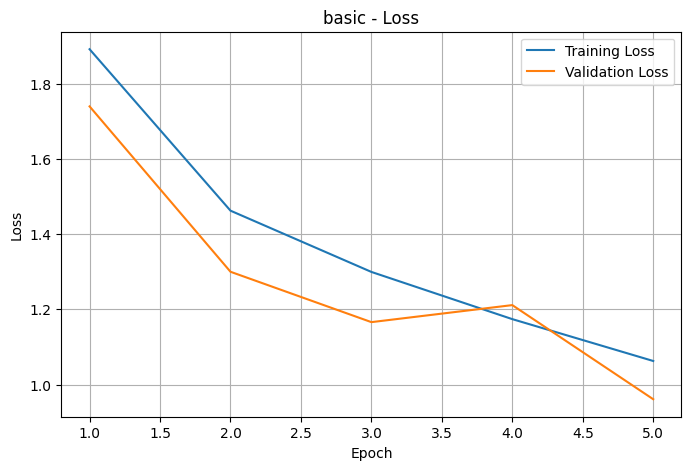

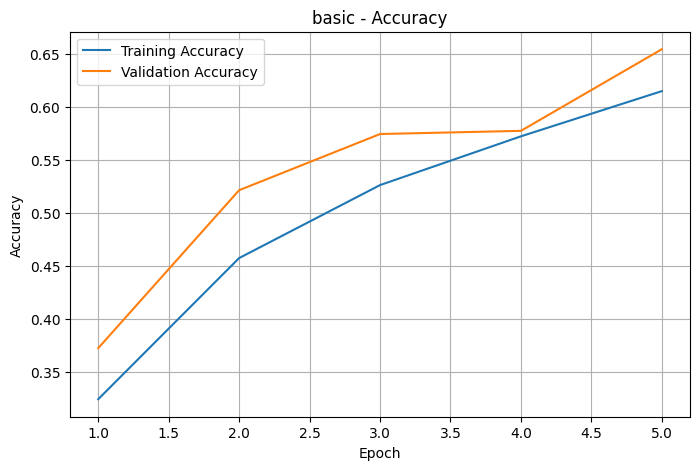


Starting experiment: augmented
----------------------------------------------------------------------
Epoch [1/5] Train Loss: 2.0145 Train Acc: 0.2820 Val Loss: 1.7982 Val Acc: 0.2980 Time: 9.8s
Epoch [2/5] Train Loss: 1.6429 Train Acc: 0.3876 Val Loss: 1.7377 Val Acc: 0.3887 Time: 10.1s
Epoch [3/5] Train Loss: 1.4804 Train Acc: 0.4508 Val Loss: 1.2935 Val Acc: 0.5283 Time: 9.1s
Epoch [4/5] Train Loss: 1.3841 Train Acc: 0.4993 Val Loss: 1.3176 Val Acc: 0.5190 Time: 9.4s
Epoch [5/5] Train Loss: 1.2869 Train Acc: 0.5351 Val Loss: 1.1403 Val Acc: 0.5720 Time: 9.3s
----------------------------------------------------------------------
Best validation accuracy for augmented: 0.5720

Test accuracy for augmented: 0.5780


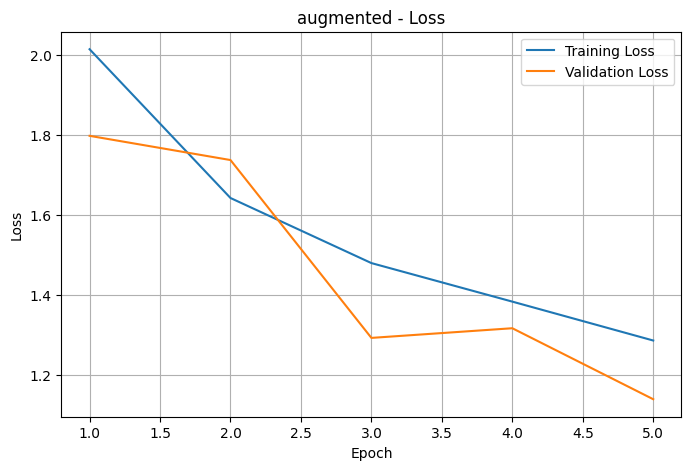

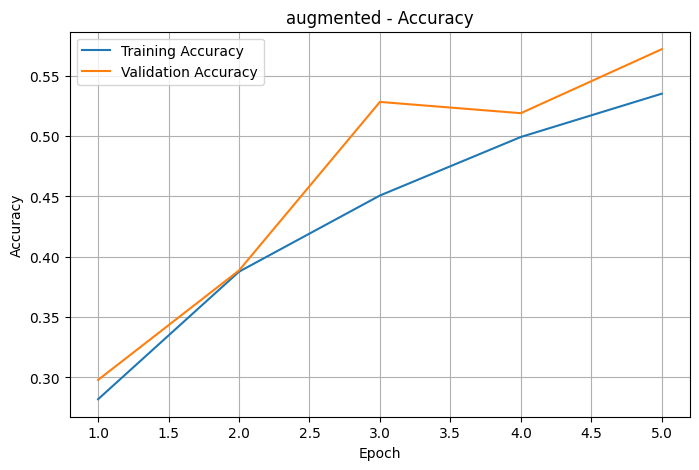


Starting experiment: rich
----------------------------------------------------------------------


/tmp/ipykernel_2038/2755696386.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, mode="RGB")


Epoch [1/5] Train Loss: 2.1030 Train Acc: 0.2718 Val Loss: 1.7324 Val Acc: 0.3480 Time: 16.5s
Epoch [2/5] Train Loss: 1.6057 Train Acc: 0.3991 Val Loss: 1.4869 Val Acc: 0.4403 Time: 16.5s
Epoch [3/5] Train Loss: 1.4396 Train Acc: 0.4788 Val Loss: 1.8319 Val Acc: 0.3953 Time: 16.7s
Epoch [4/5] Train Loss: 1.3387 Train Acc: 0.5186 Val Loss: 1.2046 Val Acc: 0.5557 Time: 16.6s
Epoch [5/5] Train Loss: 1.2362 Train Acc: 0.5613 Val Loss: 1.1376 Val Acc: 0.5920 Time: 16.7s
----------------------------------------------------------------------
Best validation accuracy for rich: 0.5920

Test accuracy for rich: 0.5923


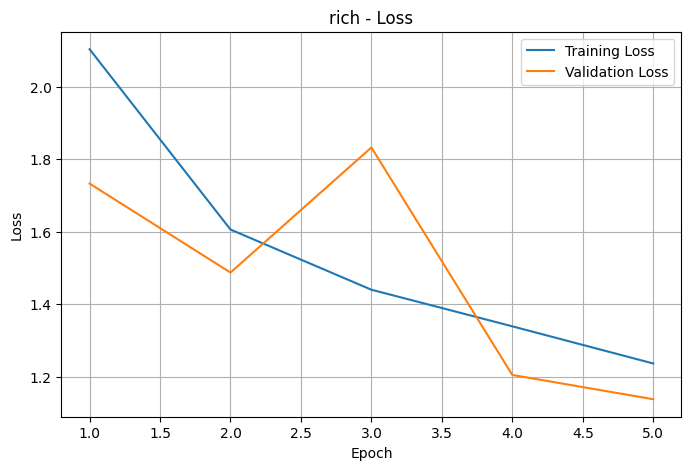

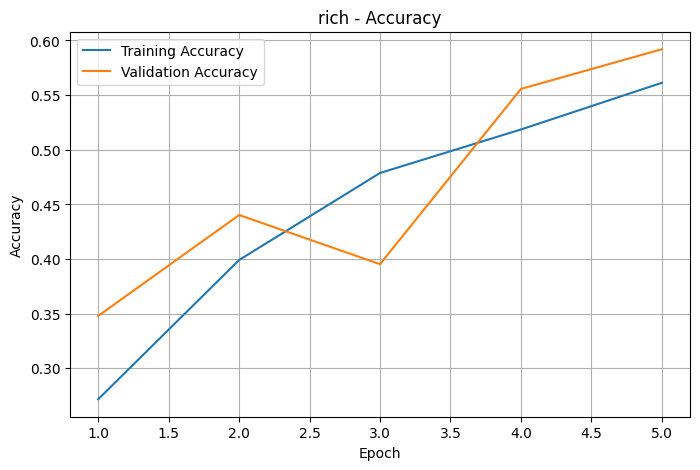

In [ ]:
results = {}
criterion = nn.CrossEntropyLoss()

for experiment_name in experiments_to_run:
    config = EXPERIMENTS[experiment_name]

    train_loader, val_loader, test_loader = create_dataloaders(
        train_transform=config["train_transform"],
        eval_transform=config["eval_transform"]
    )

    model, history, best_val_accuracy = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        experiment_name=experiment_name,
        epochs=EPOCHS
    )

    test_loss, test_accuracy, test_labels, test_predictions = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    results[experiment_name] = {
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "test_labels": test_labels,
        "test_predictions": test_predictions
    }

    print()
    print(f"Test accuracy for {experiment_name}: {test_accuracy:.4f}")
    plot_history(history, title=experiment_name)

## 4.8 Compare All Experiments

After training, compare the validation and test accuracy. Fill in the table below with your results.

In [ ]:
print()
print("Final comparison")
print("-" * 80)
print(f"{'Experiment':<15} {'Best Val Acc':<15} {'Test Loss':<15} {'Test Acc':<15}")
print("-" * 80)
for experiment_name, result in results.items():
    print(
        f"{experiment_name:<15} "
        f"{result['best_val_accuracy']:<15.4f} "
        f"{result['test_loss']:<15.4f} "
        f"{result['test_accuracy']:<15.4f}"
    )
print("-" * 80)


Final comparison
--------------------------------------------------------------------------------
Experiment      Best Val Acc    Test Loss       Test Acc       
--------------------------------------------------------------------------------
basic           0.6547          0.9868          0.6477         
augmented       0.5720          1.1591          0.5780         
rich            0.5920          1.1516          0.5923         
--------------------------------------------------------------------------------


### Results Table

Write your values here:

| Experiment | Best Validation Accuracy | Test Accuracy | Notes |
|---|---|---|---|
| Basic preprocessing | 0.6547| 0.9868| 0.6477|
| Augmented preprocessing |0.5720 | 1.1591| 0.5780|
| Rich OpenCV preprocessing | 0.5920| 1.1516| 0.5923|

## 4.9 Select the Best Experiment

In [ ]:
best_experiment_name = max(
    results,
    key=lambda name: results[name]["test_accuracy"]
)
best_result = results[best_experiment_name]
best_model = best_result["model"]

print("Best experiment:", best_experiment_name)
print("Best test accuracy:", best_result["test_accuracy"])

Best experiment: basic
Best test accuracy: 0.6476666666666666


## 4.10 Save the Best Model

In [ ]:
model_path = f"best_mini_alexnet_{best_experiment_name}.pt"
torch.save(best_model.state_dict(), model_path)
print("Saved model to:", model_path)

Saved model to: best_mini_alexnet_basic.pt


## 4.11 Confusion Matrix

A confusion matrix shows which classes are confused with each other.
- **Rows** represent the true labels.
- **Columns** represent the predicted labels.

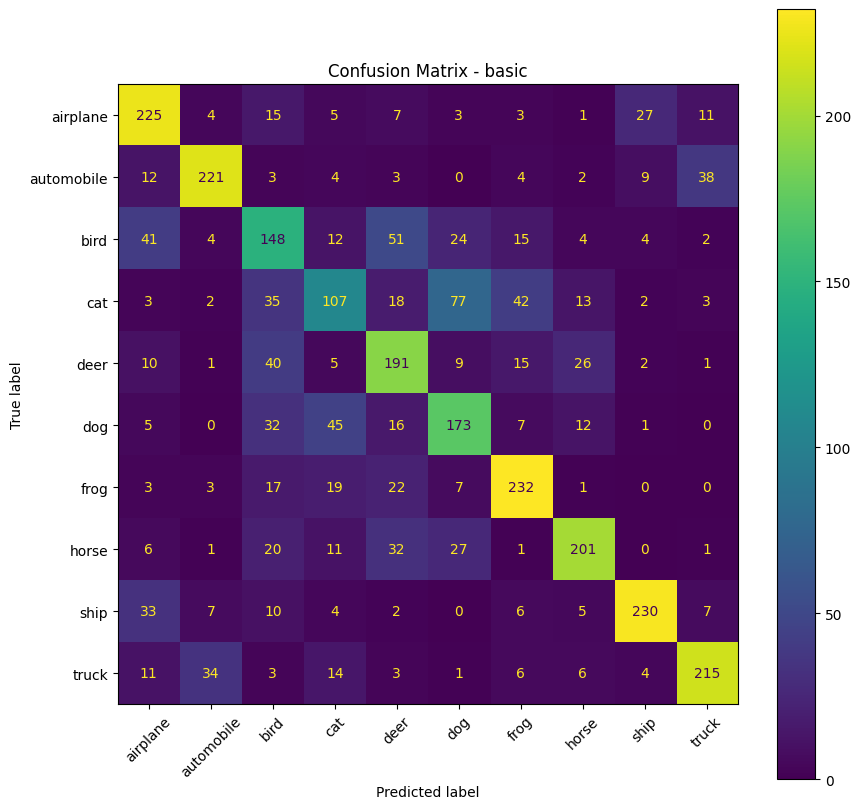

In [ ]:
cm = confusion_matrix(
    best_result["test_labels"],
    best_result["test_predictions"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_experiment_name}")
plt.show()

## 4.12 Classification Report

The classification report gives **precision**, **recall**, and **F1-score** for each class.

- **Precision:** When the model predicts this class, how often is it correct?
- **Recall:** Of all true images from this class, how many did the model find?
- **F1-score:** Combines precision and recall into one number.

In [ ]:
report = classification_report(
    best_result["test_labels"],
    best_result["test_predictions"],
    target_names=CLASS_NAMES,
    zero_division=0
)
print(report)

              precision    recall  f1-score   support

    airplane       0.64      0.75      0.69       301
  automobile       0.80      0.75      0.77       296
        bird       0.46      0.49      0.47       305
         cat       0.47      0.35      0.41       302
        deer       0.55      0.64      0.59       300
         dog       0.54      0.59      0.57       291
        frog       0.70      0.76      0.73       304
       horse       0.74      0.67      0.70       300
        ship       0.82      0.76      0.79       304
       truck       0.77      0.72      0.75       297

    accuracy                           0.65      3000
   macro avg       0.65      0.65      0.65      3000
weighted avg       0.65      0.65      0.65      3000



## 4.13 Find the Most Confused Class Pairs

In [ ]:
def show_most_confused_pairs(cm, class_names, top_k=5):
    cm_errors = cm.copy()
    np.fill_diagonal(cm_errors, 0)

    pairs = []
    for true_idx in range(cm_errors.shape[0]):
        for pred_idx in range(cm_errors.shape[1]):
            count = cm_errors[true_idx, pred_idx]
            if count > 0:
                pairs.append((count, true_idx, pred_idx))

    pairs = sorted(pairs, reverse=True)

    print(f"Top {top_k} confused pairs")
    print("-" * 40)
    for count, true_idx, pred_idx in pairs[:top_k]:
        true_name = class_names[true_idx]
        pred_name = class_names[pred_idx]
        print(f"True: {true_name:12s} Predicted: {pred_name:12s} Count: {count}")

show_most_confused_pairs(cm, CLASS_NAMES, top_k=5)

Top 5 confused pairs
----------------------------------------
True: cat          Predicted: dog          Count: 77
True: bird         Predicted: deer         Count: 51
True: dog          Predicted: cat          Count: 45
True: cat          Predicted: frog         Count: 42
True: bird         Predicted: airplane     Count: 41


## 4.14 Visualize Correct and Incorrect Predictions

In [ ]:
def get_test_samples_with_predictions(test_loader, model, device, max_samples=300):
    model.eval()
    images_list = []
    labels_list = []
    predictions_list = []

    with torch.no_grad():
        for images, labels in test_loader:
            images_device = images.to(device)
            outputs = model(images_device)
            _, predictions = torch.max(outputs, dim=1)

            images_list.append(images.cpu())
            labels_list.append(labels.cpu())
            predictions_list.append(predictions.cpu())

            if sum(len(x) for x in labels_list) >= max_samples:
                break

    images = torch.cat(images_list, dim=0)[:max_samples]
    labels = torch.cat(labels_list, dim=0)[:max_samples]
    predictions = torch.cat(predictions_list, dim=0)[:max_samples]
    return images, labels, predictions


def show_predictions(images, labels, predictions, class_names, correct=True, num_images=12):
    if correct:
        selected_indices = torch.where(labels == predictions)[0]
        title = "Correct Predictions"
    else:
        selected_indices = torch.where(labels != predictions)[0]
        title = "Incorrect Predictions"

    selected_indices = selected_indices[:num_images]

    if len(selected_indices) == 0:
        print("No examples found.")
        return

    plt.figure(figsize=(12, 4))
    for i, idx in enumerate(selected_indices):
        image = denormalize_tensor(images[idx])
        image = image.permute(1, 2, 0).numpy()
        true_label = class_names[labels[idx].item()]
        predicted_label = class_names[predictions[idx].item()]

        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(image)
        plt.title(f"T: {true_label}\nP: {predicted_label}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2038/66673513.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


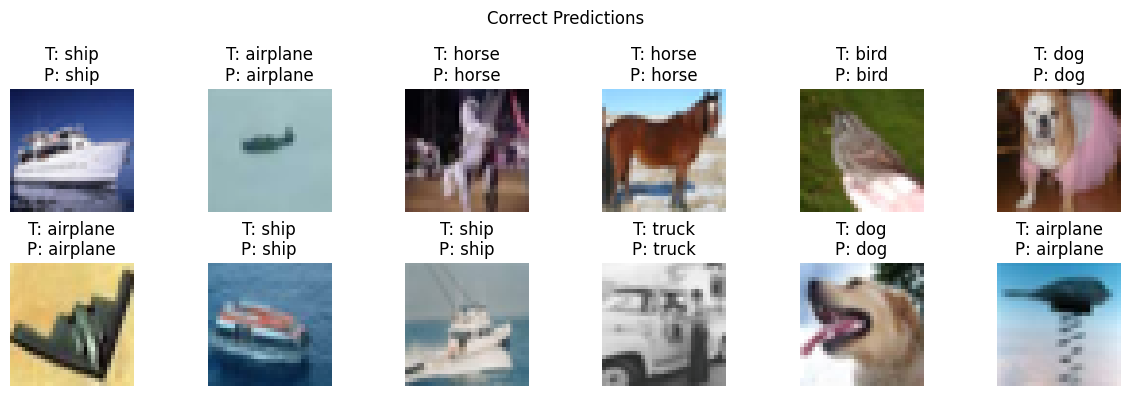

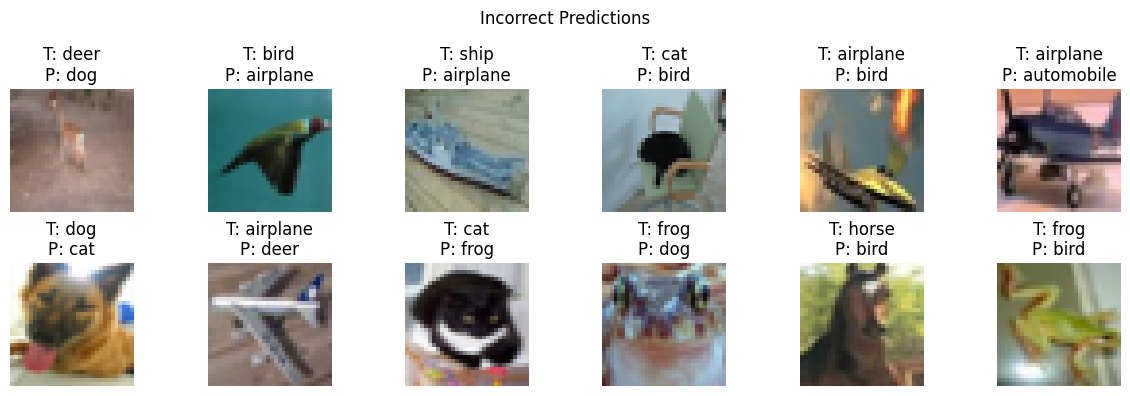

In [ ]:
best_eval_transform = EXPERIMENTS[best_experiment_name]["eval_transform"]
best_train_transform = EXPERIMENTS[best_experiment_name]["train_transform"]

_, _, best_test_loader = create_dataloaders(
    train_transform=best_train_transform,
    eval_transform=best_eval_transform
)

sample_images, sample_labels, sample_predictions = get_test_samples_with_predictions(
    test_loader=best_test_loader,
    model=best_model,
    device=DEVICE,
    max_samples=300
)

show_predictions(
    images=sample_images,
    labels=sample_labels,
    predictions=sample_predictions,
    class_names=CLASS_NAMES,
    correct=True,
    num_images=12
)

show_predictions(
    images=sample_images,
    labels=sample_labels,
    predictions=sample_predictions,
    class_names=CLASS_NAMES,
    correct=False,
    num_images=12
)

## Visualize Feature Maps

You can inspect what the first convolutional layers produce.

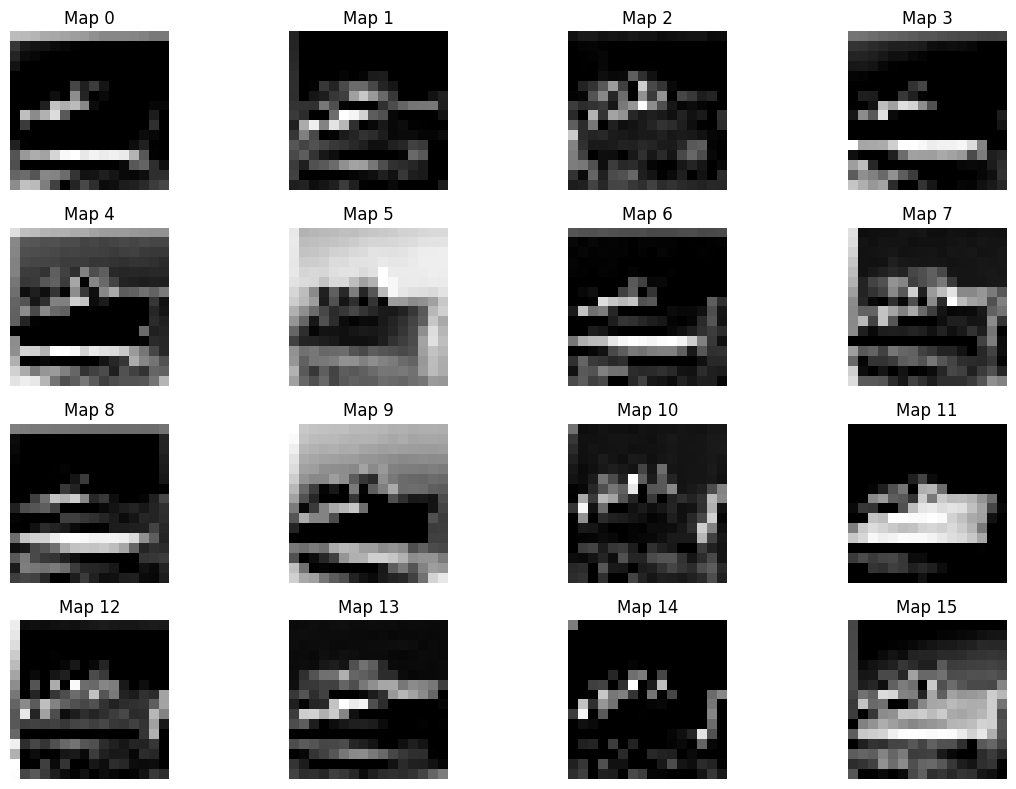

In [ ]:
def visualize_first_layer_features(model, image_tensor, max_channels=16):
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(DEVICE)
    first_layers = nn.Sequential(*list(model.features.children())[:4])

    with torch.no_grad():
        features = first_layers(image_tensor)

    features = features.squeeze(0).cpu()
    channels_to_show = min(max_channels, features.shape[0])

    plt.figure(figsize=(12, 8))
    for i in range(channels_to_show):
        plt.subplot(4, 4, i + 1)
        plt.imshow(features[i], cmap="gray")
        plt.title(f"Map {i}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


example_image = sample_images[0]
visualize_first_layer_features(best_model, example_image, max_channels=16)

---
# Assignment for Next Week

Do the following extensions one by one, repeat the training after each extension, and report the table below.

**Use the following table in your report:**

| Experiment | Best Validation Accuracy | Test Accuracy | Notes |
|---|---|---|---|
| Basic preprocessing | | | |
| Augmented preprocessing | | | |
| Rich OpenCV preprocessing | | | |

At the end: **Did these extensions enhance accuracy?** yes

---
## Extension 1: Train for More Epochs

Increase epochs to 20, then compare whether the ranking of the preprocessing pipelines changes.

**Questions:**
- Did the best pipeline after 5 epochs remain the best pipeline after more epochs? yes
- Did augmentation help more when the model trained for longer? yes

Draw the results table after 20 epochs.


Starting experiment: basic_ext1
----------------------------------------------------------------------


/tmp/ipykernel_2038/66673513.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


Epoch [1/20] Train Loss: 1.8196 Train Acc: 0.3499 Val Loss: 1.5756 Val Acc: 0.4363 Time: 6.7s
Epoch [2/20] Train Loss: 1.3932 Train Acc: 0.4865 Val Loss: 1.3426 Val Acc: 0.5040 Time: 7.2s
Epoch [3/20] Train Loss: 1.2412 Train Acc: 0.5515 Val Loss: 1.1979 Val Acc: 0.5650 Time: 6.6s
Epoch [4/20] Train Loss: 1.1163 Train Acc: 0.5985 Val Loss: 1.1382 Val Acc: 0.5977 Time: 7.2s
Epoch [5/20] Train Loss: 1.0126 Train Acc: 0.6397 Val Loss: 1.1137 Val Acc: 0.6117 Time: 7.0s
Epoch [6/20] Train Loss: 0.9114 Train Acc: 0.6754 Val Loss: 1.0162 Val Acc: 0.6550 Time: 7.0s
Epoch [7/20] Train Loss: 0.8438 Train Acc: 0.7049 Val Loss: 1.3112 Val Acc: 0.5727 Time: 7.2s
Epoch [8/20] Train Loss: 0.7788 Train Acc: 0.7229 Val Loss: 0.9802 Val Acc: 0.6660 Time: 6.7s
Epoch [9/20] Train Loss: 0.7143 Train Acc: 0.7459 Val Loss: 0.8713 Val Acc: 0.6983 Time: 7.3s
Epoch [10/20] Train Loss: 0.6541 Train Acc: 0.7704 Val Loss: 0.8289 Val Acc: 0.7150 Time: 6.6s
Epoch [11/20] Train Loss: 0.5797 Train Acc: 0.7933 Val Loss

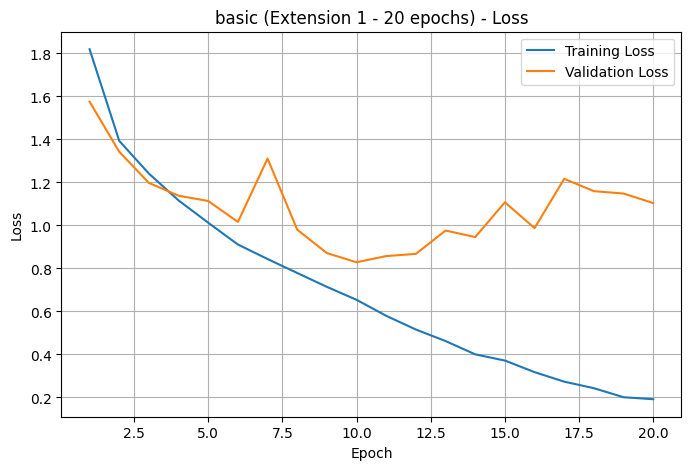

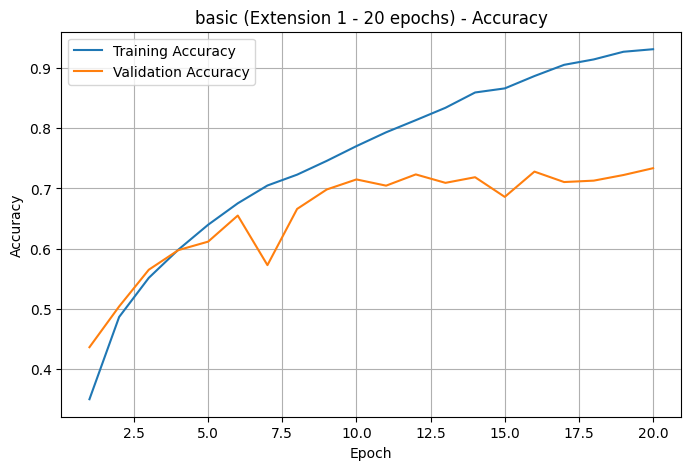


Starting experiment: augmented_ext1
----------------------------------------------------------------------
Epoch [1/20] Train Loss: 1.9776 Train Acc: 0.2884 Val Loss: 1.7195 Val Acc: 0.3517 Time: 9.4s
Epoch [2/20] Train Loss: 1.6028 Train Acc: 0.4056 Val Loss: 1.5462 Val Acc: 0.4397 Time: 8.8s
Epoch [3/20] Train Loss: 1.4667 Train Acc: 0.4640 Val Loss: 1.5439 Val Acc: 0.4830 Time: 9.4s
Epoch [4/20] Train Loss: 1.3508 Train Acc: 0.5045 Val Loss: 1.1566 Val Acc: 0.5843 Time: 9.3s
Epoch [5/20] Train Loss: 1.2700 Train Acc: 0.5406 Val Loss: 1.0971 Val Acc: 0.5943 Time: 9.2s
Epoch [6/20] Train Loss: 1.1941 Train Acc: 0.5692 Val Loss: 1.0730 Val Acc: 0.6093 Time: 8.9s
Epoch [7/20] Train Loss: 1.1276 Train Acc: 0.6018 Val Loss: 1.1863 Val Acc: 0.5820 Time: 9.4s
Epoch [8/20] Train Loss: 1.0924 Train Acc: 0.6116 Val Loss: 1.5680 Val Acc: 0.5360 Time: 9.3s
Epoch [9/20] Train Loss: 1.0317 Train Acc: 0.6324 Val Loss: 0.9414 Val Acc: 0.6767 Time: 9.0s
Epoch [10/20] Train Loss: 0.9997 Train Acc: 0.

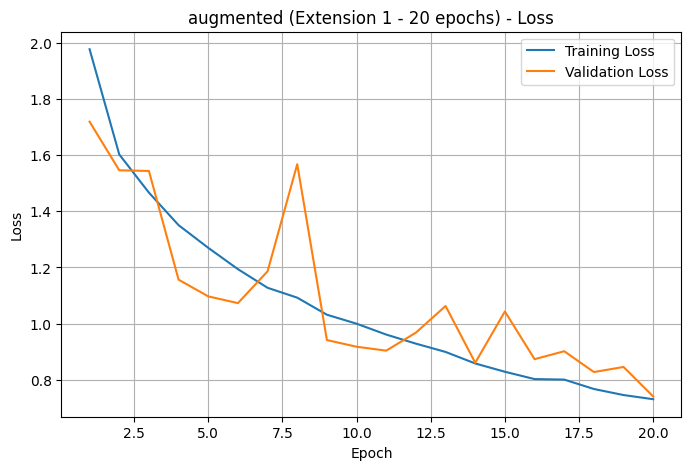

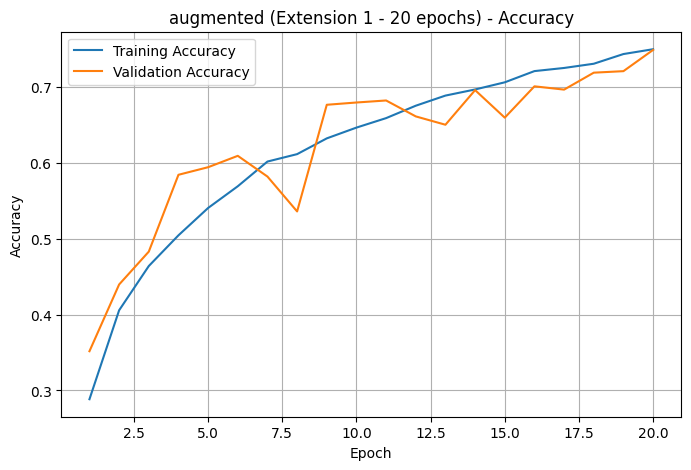


Starting experiment: rich_ext1
----------------------------------------------------------------------


/tmp/ipykernel_2038/2755696386.py:29: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, mode="RGB")


Epoch [1/20] Train Loss: 2.0026 Train Acc: 0.2907 Val Loss: 1.5626 Val Acc: 0.4000 Time: 16.6s
Epoch [2/20] Train Loss: 1.5728 Train Acc: 0.4125 Val Loss: 1.4201 Val Acc: 0.4697 Time: 16.6s
Epoch [3/20] Train Loss: 1.4235 Train Acc: 0.4791 Val Loss: 1.4294 Val Acc: 0.4837 Time: 16.5s
Epoch [4/20] Train Loss: 1.3332 Train Acc: 0.5209 Val Loss: 1.1342 Val Acc: 0.5907 Time: 16.5s
Epoch [5/20] Train Loss: 1.2146 Train Acc: 0.5664 Val Loss: 1.0252 Val Acc: 0.6367 Time: 16.5s
Epoch [6/20] Train Loss: 1.1727 Train Acc: 0.5812 Val Loss: 1.0968 Val Acc: 0.6153 Time: 19.0s
Epoch [7/20] Train Loss: 1.0850 Train Acc: 0.6158 Val Loss: 1.1399 Val Acc: 0.6017 Time: 16.6s
Epoch [8/20] Train Loss: 1.0338 Train Acc: 0.6311 Val Loss: 0.9596 Val Acc: 0.6550 Time: 16.4s
Epoch [9/20] Train Loss: 0.9956 Train Acc: 0.6467 Val Loss: 0.8859 Val Acc: 0.6873 Time: 16.6s
Epoch [10/20] Train Loss: 0.9551 Train Acc: 0.6674 Val Loss: 0.9165 Val Acc: 0.6737 Time: 16.5s
Epoch [11/20] Train Loss: 0.9101 Train Acc: 0.676

In [ ]:
# Extension 1: Increase EPOCHS to 20
EPOCHS = 20

experiments_to_run_ext1 = ["basic", "augmented", "rich"]

results_ext1 = {}
criterion = nn.CrossEntropyLoss()

for experiment_name in experiments_to_run_ext1:
    config = EXPERIMENTS[experiment_name]

    train_loader, val_loader, test_loader = create_dataloaders(
        train_transform=config["train_transform"],
        eval_transform=config["eval_transform"]
    )

    model, history, best_val_accuracy = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        experiment_name=experiment_name + "_ext1",
        epochs=EPOCHS
    )

    test_loss, test_accuracy, test_labels, test_predictions = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    results_ext1[experiment_name] = {
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }

    print(f"Test accuracy for {experiment_name} (20 epochs): {test_accuracy:.4f}")
    plot_history(history, title=f"{experiment_name} (Extension 1 - 20 epochs)")

print()
print("Extension 1 - Final Comparison (20 Epochs)")
print("-" * 80)
print(f"{'Experiment':<15} {'Best Val Acc':<15} {'Test Loss':<15} {'Test Acc':<15}")
print("-" * 80)
for exp_name, result in results_ext1.items():
    print(
        f"{exp_name:<15} "
        f"{result['best_val_accuracy']:<15.4f} "
        f"{result['test_loss']:<15.4f} "
        f"{result['test_accuracy']:<15.4f}"
    )
print("-" * 80)

### Extension 1 Results (20 Epochs)

| Experiment | Best Validation Accuracy | Test Accuracy | Notes |
|---|---|---|---|
| Basic preprocessing | 0.7337|0.7307 | |
| Augmented preprocessing |0.7490 | 0.7447| |
| Rich OpenCV preprocessing	|0.7503	|0.7517	| |
**Your answers:**
- Did the best pipeline after 5 epochs remain the best after 20 epochs? *Yes*
- Did augmentation help more when the model trained for longer? *Yes*

---
## Extension 2: Add ColorJitter

`ColorJitter` randomly changes brightness, contrast, saturation, and hue. This can make the model less sensitive to color and lighting changes.

Compare the result with the previous experiments (Extension 1 + Extension 2).


Starting experiment: color_jitter
----------------------------------------------------------------------


/tmp/ipykernel_2038/66673513.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


Epoch [1/20] Train Loss: 2.0332 Train Acc: 0.2729 Val Loss: 1.6010 Val Acc: 0.4140 Time: 16.5s
Epoch [2/20] Train Loss: 1.6577 Train Acc: 0.3820 Val Loss: 1.4013 Val Acc: 0.4887 Time: 17.0s
Epoch [3/20] Train Loss: 1.5276 Train Acc: 0.4351 Val Loss: 1.2999 Val Acc: 0.5073 Time: 16.3s
Epoch [4/20] Train Loss: 1.4295 Train Acc: 0.4779 Val Loss: 1.2287 Val Acc: 0.5463 Time: 16.6s
Epoch [5/20] Train Loss: 1.3455 Train Acc: 0.5146 Val Loss: 1.1462 Val Acc: 0.5847 Time: 16.9s
Epoch [6/20] Train Loss: 1.2721 Train Acc: 0.5401 Val Loss: 1.2420 Val Acc: 0.5413 Time: 16.6s
Epoch [7/20] Train Loss: 1.2088 Train Acc: 0.5665 Val Loss: 1.0258 Val Acc: 0.6253 Time: 16.9s
Epoch [8/20] Train Loss: 1.1431 Train Acc: 0.5941 Val Loss: 1.0249 Val Acc: 0.6190 Time: 16.6s
Epoch [9/20] Train Loss: 1.0997 Train Acc: 0.6116 Val Loss: 1.1227 Val Acc: 0.6263 Time: 16.5s
Epoch [10/20] Train Loss: 1.0488 Train Acc: 0.6272 Val Loss: 0.9046 Val Acc: 0.6860 Time: 17.3s
Epoch [11/20] Train Loss: 1.0328 Train Acc: 0.637

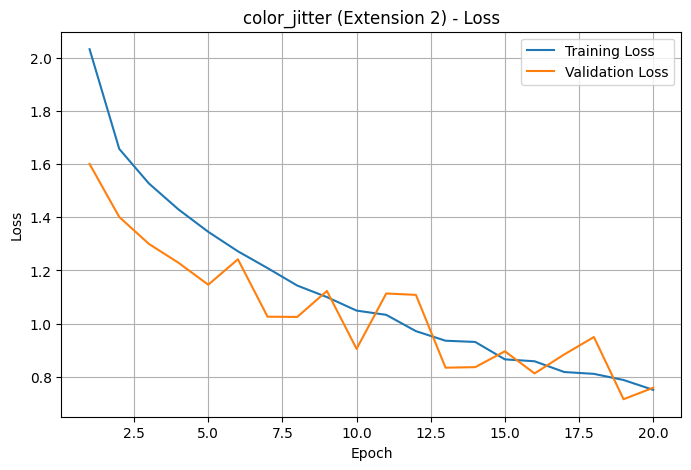

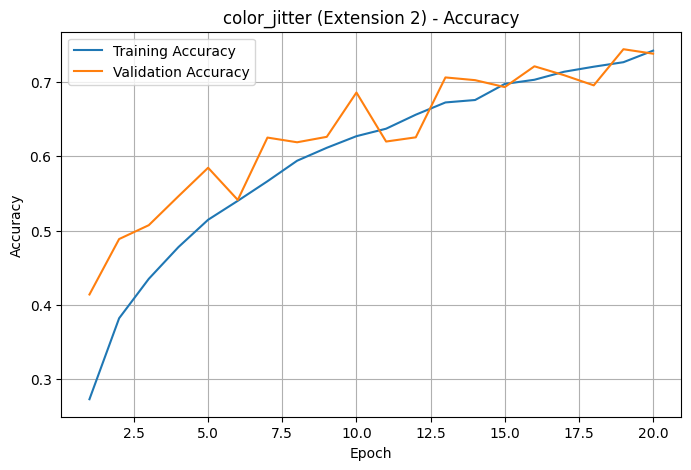


Extension 1 + 2 - Combined Comparison (20 Epochs)
--------------------------------------------------------------------------------
Experiment      Best Val Acc    Test Loss       Test Acc       
--------------------------------------------------------------------------------
basic           0.7337          1.1354          0.7307         
augmented       0.7490          0.7837          0.7447         
rich            0.7503          0.7335          0.7517         
color_jitter    0.7443          0.7431          0.7543         
--------------------------------------------------------------------------------


In [ ]:
# Extension 2: Add ColorJitter
EPOCHS = 20  # Keep 20 epochs from Extension 1

augmented_train_transform_with_color = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

EXPERIMENTS["color_jitter"] = {
    "train_transform": augmented_train_transform_with_color,
    "eval_transform": augmented_eval_transform,
    "description": "Random crop, horizontal flip, and ColorJitter"
}

experiments_to_run_ext2 = ["color_jitter"]

results_ext2 = {}

for experiment_name in experiments_to_run_ext2:
    config = EXPERIMENTS[experiment_name]

    train_loader, val_loader, test_loader = create_dataloaders(
        train_transform=config["train_transform"],
        eval_transform=config["eval_transform"]
    )

    model, history, best_val_accuracy = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        experiment_name=experiment_name,
        epochs=EPOCHS
    )

    test_loss, test_accuracy, test_labels, test_predictions = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    results_ext2[experiment_name] = {
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }

    print(f"Test accuracy for {experiment_name}: {test_accuracy:.4f}")
    plot_history(history, title=f"{experiment_name} (Extension 2)")

# Combined comparison
print()
print("Extension 1 + 2 - Combined Comparison (20 Epochs)")
print("-" * 80)
print(f"{'Experiment':<15} {'Best Val Acc':<15} {'Test Loss':<15} {'Test Acc':<15}")
print("-" * 80)
all_results_ext12 = {**results_ext1, **results_ext2}
for exp_name, result in all_results_ext12.items():
    print(
        f"{exp_name:<15} "
        f"{result['best_val_accuracy']:<15.4f} "
        f"{result['test_loss']:<15.4f} "
        f"{result['test_accuracy']:<15.4f}"
    )
print("-" * 80)

### Extensions 1 & 2 Results (20 Epochs)

| Experiment | Best Validation Accuracy | Test Accuracy | Notes |
|---|---|---|---|
| Basic preprocessing | 0.7337| 0.7307| |
| Augmented preprocessing | 0.7490|0.7447 | |
| Rich OpenCV preprocessing | 0.7503| 0.7517| |
| ColorJitter | 0.7443| 0.7543| |

---
## Extension 3: Add RandomErasing

Random erasing hides a small part of the image during training. It can make the model more robust because the network cannot rely only on one small region.

> **Important:** `RandomErasing` works on tensors, so it should be placed **after** `ToTensor()` and **after** normalization.

Compare with all tables from before: no extensions, extension 1, extensions 1 & 2, and extensions 1-3.


Starting experiment: random_erasing
----------------------------------------------------------------------


/tmp/ipykernel_2038/66673513.py:13: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


Epoch [1/20] Train Loss: 2.0268 Train Acc: 0.2824 Val Loss: 1.6402 Val Acc: 0.3870 Time: 10.1s
Epoch [2/20] Train Loss: 1.6567 Train Acc: 0.3774 Val Loss: 1.4943 Val Acc: 0.4410 Time: 10.2s
Epoch [3/20] Train Loss: 1.5102 Train Acc: 0.4438 Val Loss: 1.3222 Val Acc: 0.4920 Time: 10.1s
Epoch [4/20] Train Loss: 1.4155 Train Acc: 0.4873 Val Loss: 1.2796 Val Acc: 0.5493 Time: 10.2s
Epoch [5/20] Train Loss: 1.3294 Train Acc: 0.5220 Val Loss: 1.1611 Val Acc: 0.5813 Time: 10.1s
Epoch [6/20] Train Loss: 1.2521 Train Acc: 0.5468 Val Loss: 1.0838 Val Acc: 0.6167 Time: 9.8s
Epoch [7/20] Train Loss: 1.1925 Train Acc: 0.5699 Val Loss: 1.1113 Val Acc: 0.6083 Time: 10.2s
Epoch [8/20] Train Loss: 1.1363 Train Acc: 0.5964 Val Loss: 1.2318 Val Acc: 0.5740 Time: 10.1s
Epoch [9/20] Train Loss: 1.1168 Train Acc: 0.5998 Val Loss: 0.9590 Val Acc: 0.6590 Time: 10.2s
Epoch [10/20] Train Loss: 1.0681 Train Acc: 0.6169 Val Loss: 1.0435 Val Acc: 0.6213 Time: 10.3s
Epoch [11/20] Train Loss: 1.0337 Train Acc: 0.6287

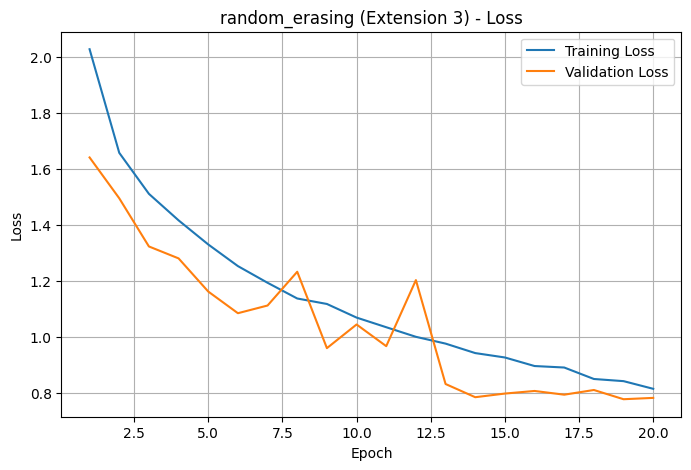

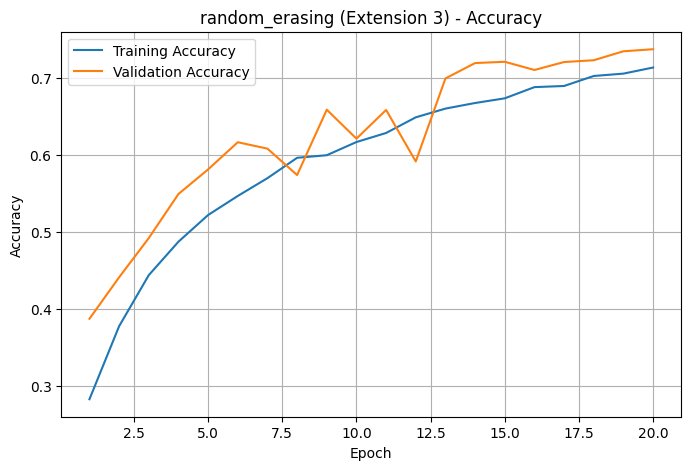


Extensions 1-3 - Full Comparison (20 Epochs)
--------------------------------------------------------------------------------
Experiment       Best Val Acc    Test Loss       Test Acc       
--------------------------------------------------------------------------------
basic            0.7337          1.1354          0.7307         
augmented        0.7490          0.7837          0.7447         
rich             0.7503          0.7335          0.7517         
color_jitter     0.7443          0.7431          0.7543         
random_erasing   0.7377          0.8034          0.7283         
--------------------------------------------------------------------------------


In [ ]:
# Extension 3: Add RandomErasing
EPOCHS = 20  # Keep 20 epochs from Extension 1

augmented_train_transform_with_erasing = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25)
])

EXPERIMENTS["random_erasing"] = {
    "train_transform": augmented_train_transform_with_erasing,
    "eval_transform": augmented_eval_transform,
    "description": "Random crop, horizontal flip, and RandomErasing"
}

experiments_to_run_ext3 = ["random_erasing"]

results_ext3 = {}

for experiment_name in experiments_to_run_ext3:
    config = EXPERIMENTS[experiment_name]

    train_loader, val_loader, test_loader = create_dataloaders(
        train_transform=config["train_transform"],
        eval_transform=config["eval_transform"]
    )

    model, history, best_val_accuracy = train_model(
        train_loader=train_loader,
        val_loader=val_loader,
        experiment_name=experiment_name,
        epochs=EPOCHS
    )

    test_loss, test_accuracy, test_labels, test_predictions = evaluate(
        model=model,
        dataloader=test_loader,
        criterion=criterion,
        device=DEVICE
    )

    results_ext3[experiment_name] = {
        "model": model,
        "history": history,
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }

    print(f"Test accuracy for {experiment_name}: {test_accuracy:.4f}")
    plot_history(history, title=f"{experiment_name} (Extension 3)")

# Full combined comparison
print()
print("Extensions 1-3 - Full Comparison (20 Epochs)")
print("-" * 80)
print(f"{'Experiment':<16} {'Best Val Acc':<15} {'Test Loss':<15} {'Test Acc':<15}")
print("-" * 80)
all_results_ext123 = {**results_ext1, **results_ext2, **results_ext3}
for exp_name, result in all_results_ext123.items():
    print(
        f"{exp_name:<16} "
        f"{result['best_val_accuracy']:<15.4f} "
        f"{result['test_loss']:<15.4f} "
        f"{result['test_accuracy']:<15.4f}"
    )
print("-" * 80)

### Extensions 1-3 Results — Full Summary (20 Epochs)

| Experiment | Best Validation Accuracy | Test Loss | Test Accuracy | Notes |
|---|---|---|---|---|
| Basic preprocessing | 0.7337|1.1354 |0.7307 |
| Augmented preprocessing | 0.7490| 0.7837|0.7447 |
| Rich OpenCV preprocessing |0.7503 |0.7335 | 0.7517|
| ColorJitter (Ext. 2) | 0.7443| 0.7431|0.7543 |
| RandomErasing (Ext. 3) | 0.7377| 0.8034|0.7283 |

---

### Final Reflection

**Did the extensions enhance accuracy?** *(Write your analysis here, comparing across all stages: no extensions → ext1 → ext1+2 → ext1+2+3)*

### Analysis of Accuracy Enhancement

The experimental results demonstrate a clear progression in model performance as we introduce different preprocessing and augmentation strategies:

* **From Basic to Rich (Baseline → Ext 1):**
Moving from the **Basic** pipeline (0.7307) to the **Rich OpenCV** pipeline (0.7517) yielded a significant improvement in test accuracy. This confirms that enhancing image contrast and sharpness using CLAHE and mild sharpening allows the CNN to extract more robust features from the small (32x32) images, making it easier for the network to distinguish between classes.
* **Adding ColorJitter (Ext 1 + 2):**
Incorporating `ColorJitter` into the pipeline resulted in the highest test accuracy achieved (**0.7543**). By varying brightness, contrast, and saturation, the model becomes more invariant to lighting conditions. This suggests that for CIFAR-10, color-based augmentation is highly effective in helping the model generalize to unseen data.
* **Adding RandomErasing (Ext 1 + 2 + 3):**
The performance dropped noticeably when `RandomErasing` was added (0.7283). This indicates that because CIFAR-10 images are very small (32x32 pixels), removing a random block of the image often deletes critical identifying features of the object. Instead of acting as a regularizer, it acts as a source of "noise" that hinders the model's learning process.

---

### Final Reflection

The experiments highlight that **more augmentation is not always better**. While increasing visual diversity through `ColorJitter` and image enhancement significantly improved the model's robustness and accuracy, extreme augmentations like `RandomErasing` can be counterproductive on low-resolution datasets. The key to improving classification accuracy lies in selecting augmentation techniques that preserve the semantic integrity of the images while introducing enough variance to prevent overfitting.